# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---

## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.

### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


 Primeras 5 filas del dataset 


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710



Total de muestras  : 19937
Total de columnas  : 529
  ├─ Columnas WAP  : 520
  └─ Otras columnas: 9

 Distribución de clases en FLOOR 
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102

Número de clases distintas: 5


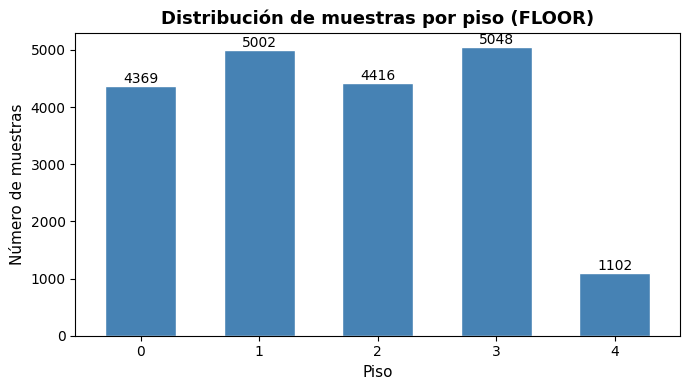

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset de entrenamiento
df = pd.read_csv('trainingData (1).csv')

# ── Primeras filas
print(" Primeras 5 filas del dataset ")
display(df.head())

# ── Dimensiones
n_muestras, n_columnas = df.shape
n_wap = len([c for c in df.columns if c.startswith('WAP')])
print(f"\nTotal de muestras  : {n_muestras}")
print(f"Total de columnas  : {n_columnas}")
print(f"  ├─ Columnas WAP  : {n_wap}")
print(f"  └─ Otras columnas: {n_columnas - n_wap}")

# ── Distribución de la variable objetivo
print("\n Distribución de clases en FLOOR ")
floor_counts = df['FLOOR'].value_counts().sort_index()
print(floor_counts.to_string())
print(f"\nNúmero de clases distintas: {df['FLOOR'].nunique()}")

# ── Gráfico de distribución
fig, ax = plt.subplots(figsize=(7, 4))
floor_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
ax.set_title('Distribución de muestras por piso (FLOOR)', fontsize=13, fontweight='bold')
ax.set_xlabel('Piso', fontsize=11)
ax.set_ylabel('Número de muestras', fontsize=11)
ax.set_xticklabels(floor_counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [ ]:
# ── Columnas a eliminar ─
cols_a_eliminar = ['LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION',
                   'USERID', 'PHONEID', 'TIMESTAMP', 'BUILDINGID']

cols_existentes = [c for c in cols_a_eliminar if c in df.columns]
df_limpio = df.drop(columns=cols_existentes)

print(f"Columnas eliminadas : {cols_existentes}")
print(f"Columnas restantes  : {df_limpio.shape[1]}")

# ── Separación de X e y ─
wap_cols = [c for c in df_limpio.columns if c.startswith('WAP')]
X = df_limpio[wap_cols].copy()
y = df_limpio['FLOOR'].copy()

print(f"\nForma de X (features) : {X.shape}")
print(f"Forma de y (objetivo)  : {y.shape}")

# ── Verificación de valores atípicos en WAP ─
print("\n Análisis de valores en columnas WAP ")
unique_vals_sample = X.stack().value_counts()
print(f"Total valores '100' (no detectado) : {(X == 100).sum().sum():,}")
print(f"Rango de otros valores             : [{X[X != 100].min().min():.0f}, {X[X != 100].max().max():.0f}]")
print(f"Valores nulos (NaN)                : {X.isna().sum().sum()}")


Columnas eliminadas : ['LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP', 'BUILDINGID']
Columnas restantes  : 521

Forma de X (features) : (19937, 520)
Forma de y (objetivo)  : (19937,)

 Análisis de valores en columnas WAP 
Total valores '100' (no detectado) : 10,008,477
Rango de otros valores             : [-104, 0]
Valores nulos (NaN)                : 0


---

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100
  ```


Valores '100' antes del reemplazo : 10,008,477
Valores '100' después del reemplazo: 0
Nuevo rango de valores en X        : [-104, 0]


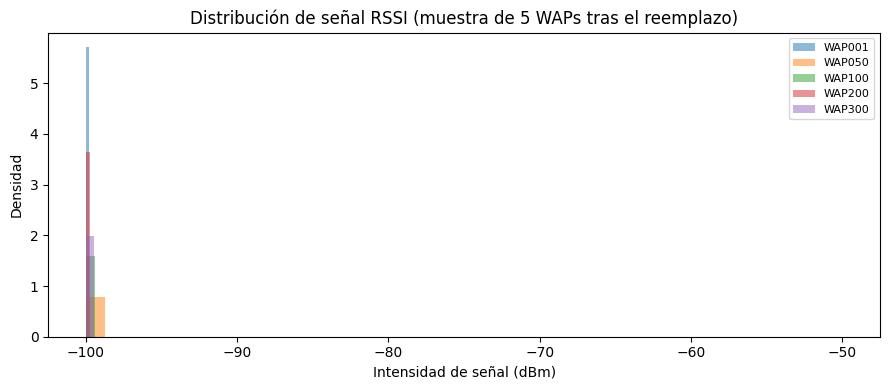

In [ ]:
# ── Reemplazo de 100 → -100 (ausencia de señal)
print(f"Valores '100' antes del reemplazo : {(X == 100).sum().sum():,}")

X[X == 100] = -100

print(f"Valores '100' después del reemplazo: {(X == 100).sum().sum():,}")
print(f"Nuevo rango de valores en X        : [{X.min().min():.0f}, {X.max().max():.0f}]")

# ── Distribución de valores RSSI (muestra aleatoria de 5 WAPs) ─
fig, ax = plt.subplots(figsize=(9, 4))
sample_waps = ['WAP001', 'WAP050', 'WAP100', 'WAP200', 'WAP300']
for wap in sample_waps:
    ax.hist(X[wap], bins=40, alpha=0.5, label=wap, density=True)
ax.set_title('Distribución de señal RSSI (muestra de 5 WAPs tras el reemplazo)', fontsize=12)
ax.set_xlabel('Intensidad de señal (dBm)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

def preparar_dataset(ruta_train: str,
                     ruta_test: str,
                     columna_objetivo: str = 'FLOOR',
                     random_state: int = 42):
    """
    Carga, limpia, normaliza y divide el dataset UJIIndoorLoc.

    Parámetros
    ----------
    ruta_train       : ruta al CSV de entrenamiento.
    ruta_test        : ruta al CSV de prueba (validationData).
    columna_objetivo : nombre de la columna a predecir (default='FLOOR').
    random_state     : semilla para reproducibilidad.

    Retorna
    -------
    X_train, X_val, X_test : arrays NumPy con features normalizadas.
    y_train, y_val, y_test : arrays NumPy con etiquetas enteras.
    scaler                 : instancia ajustada de MinMaxScaler.
    """
    cols_a_eliminar = ['LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION',
                       'USERID', 'PHONEID', 'TIMESTAMP', 'BUILDINGID']

    # ── Cargar datos ─
    df_train = pd.read_csv(ruta_train)
    df_test  = pd.read_csv(ruta_test)

    # ── Limpiar columnas irrelevantes
    for df_ in [df_train, df_test]:
        for col in cols_a_eliminar:
            if col in df_.columns:
                df_.drop(columns=col, inplace=True)

    # ── Separar X e y
    wap_cols = [c for c in df_train.columns if c.startswith('WAP')]

    X_all   = df_train[wap_cols].values.astype(np.float32)
    y_all   = df_train[columna_objetivo].values.astype(np.int64)
    X_test  = df_test[wap_cols].values.astype(np.float32)
    y_test  = df_test[columna_objetivo].values.astype(np.int64)

    # ── Reemplazar 100 → -100 (ausencia de señal)
    X_all[X_all == 100]   = -100
    X_test[X_test == 100] = -100

    # ── División entrenamiento / validación (80 / 20 estratificado)
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all,
        test_size=0.20,
        stratify=y_all,
        random_state=random_state
    )

    # ── Normalización MinMax ajustada SOLO sobre entrenamiento
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    return (X_train.astype(np.float32),
            X_val.astype(np.float32),
            X_test.astype(np.float32),
            y_train, y_val, y_test,
            scaler)


# ── Ejecutar la función
X_train, X_val, X_test, y_train, y_val, y_test, scaler = preparar_dataset(
    ruta_train='trainingData (1).csv',
    ruta_test='validationData (1).csv',
    columna_objetivo='FLOOR',
    random_state=42
)

print(" Tamaños de los conjuntos ")
print(f"  Entrenamiento : X={X_train.shape}  y={y_train.shape}")
print(f"  Validación    : X={X_val.shape}    y={y_val.shape}")
print(f"  Testeo        : X={X_test.shape}   y={y_test.shape}")

print("\n Rango de valores normalizados ")
print(f"  X_train → min={X_train.min():.4f}  max={X_train.max():.4f}")
print(f"  X_val   → min={X_val.min():.4f}    max={X_val.max():.4f}")
print(f"  X_test  → min={X_test.min():.4f}   max={X_test.max():.4f}")

print("\n Distribución de clases ")
for nombre, arr in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(arr, return_counts=True)
    dist = {int(k): int(v) for k, v in zip(unique, counts)}
    print(f"  {nombre}: {dist}")

 Tamaños de los conjuntos 
  Entrenamiento : X=(15949, 520)  y=(15949,)
  Validación    : X=(3988, 520)    y=(3988,)
  Testeo        : X=(1111, 520)   y=(1111,)

 Rango de valores normalizados 
  X_train → min=0.0000  max=1.0000
  X_val   → min=-0.0149    max=8.0000
  X_test  → min=-0.0435   max=53.0000

 Distribución de clases 
  Train: {0: 3495, 1: 4001, 2: 3533, 3: 4038, 4: 882}
  Val: {0: 874, 1: 1001, 2: 883, 3: 1010, 4: 220}
  Test: {0: 132, 1: 462, 2: 306, 3: 172, 4: 39}


---

## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size:** 32
- **Sin Dropout ni BatchNormalization**

### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```
   Input (520) → Linear(128) + ReLU → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```
   Input (520) → Linear(256) + ReLU → Linear(128) + ReLU → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```
   Input (520) → Linear(256) + ReLU → Linear(128) + ReLU → Linear(64) + ReLU → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```
   Input (520) → Linear(512) + ReLU → Linear(256) + ReLU → Linear(128) + ReLU → Linear(64) + ReLU → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```
   Input (520) → Linear(1024) + ReLU → Linear(512) + ReLU → Linear(256) + ReLU → Linear(128) + ReLU → Linear(64) + ReLU → Linear(4)
   ```


Dispositivo : cpu
Clases      : 5  |  Features: 520

────────────────────────────────────────────────────────────
  Arquitectura 1 (Compacta)
  Capas ocultas: [128]
────────────────────────────────────────────────────────────
  Época   1/20  |  Loss Train: 0.4091  |  Loss Val: 0.0762
  Época   5/20  |  Loss Train: 0.0142  |  Loss Val: 0.0222
  Época  10/20  |  Loss Train: 0.0070  |  Loss Val: 0.0179
  Época  15/20  |  Loss Train: 0.0050  |  Loss Val: 0.0168
  Época  20/20  |  Loss Train: 0.0042  |  Loss Val: 0.0186

  ✔ Test → Accuracy: 0.8785  |  F1: 0.8789  |  Tiempo: 25.2s

────────────────────────────────────────────────────────────
  Arquitectura 2 (2 capas ocultas)
  Capas ocultas: [256, 128]
────────────────────────────────────────────────────────────
  Época   1/20  |  Loss Train: 0.2133  |  Loss Val: 0.0273
  Época   5/20  |  Loss Train: 0.0105  |  Loss Val: 0.0256
  Época  10/20  |  Loss Train: 0.0089  |  Loss Val: 0.0271
  Época  15/20  |  Loss Train: 0.0069  |  Loss Val: 0.

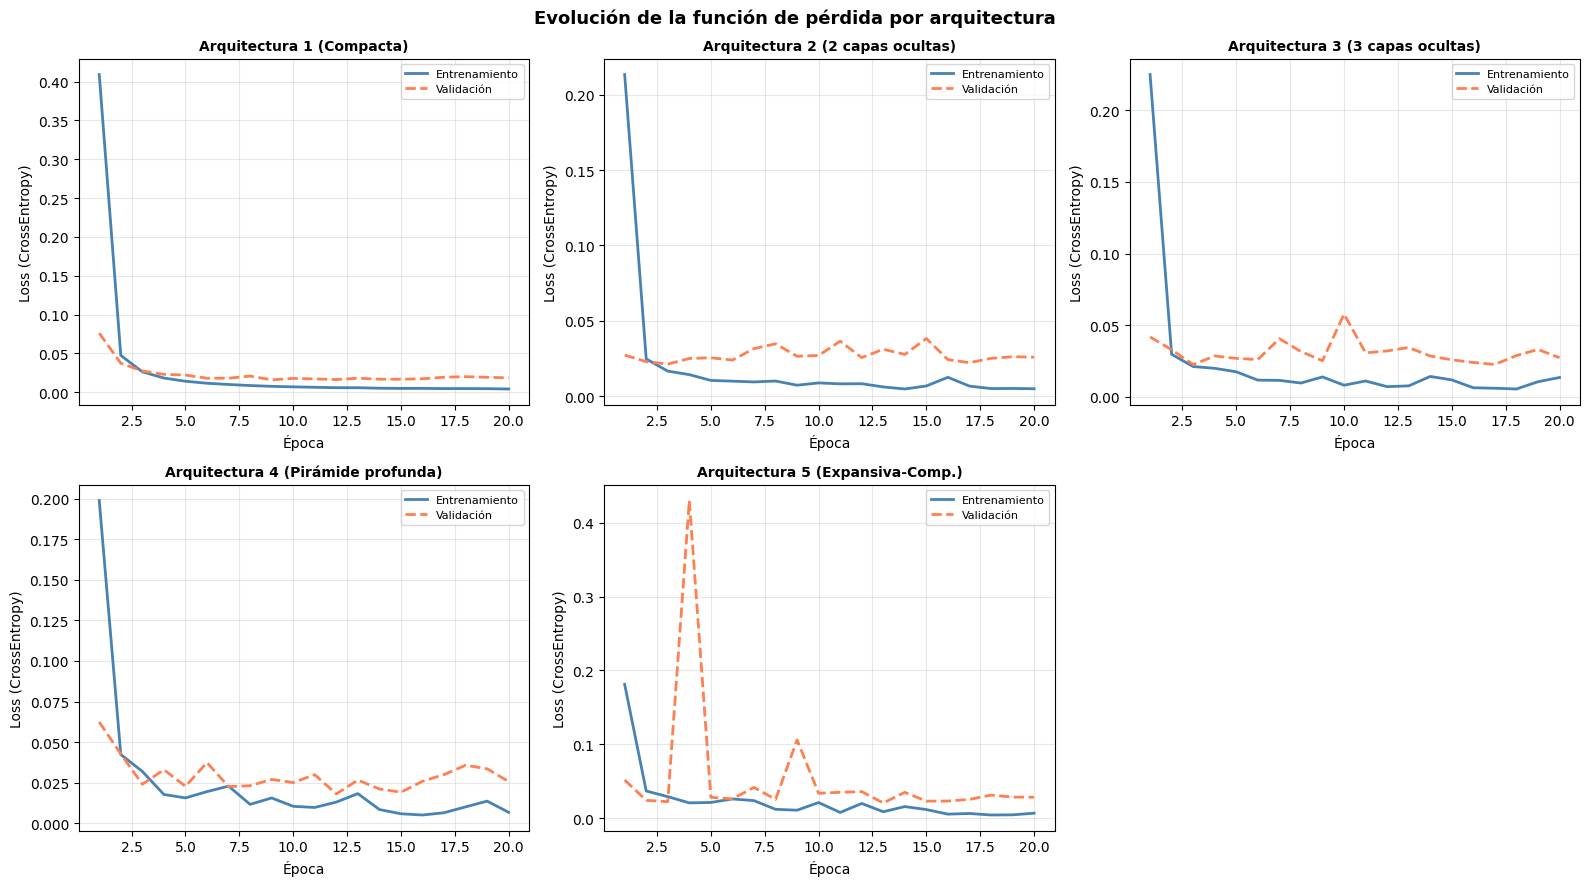

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# ── Configuración global
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS     = 20
BATCH_SIZE = 32
LR         = 1e-3
N_CLASSES  = len(np.unique(y_train))
N_FEATURES = X_train.shape[1]

print(f"Dispositivo : {DEVICE}")
print(f"Clases      : {N_CLASSES}  |  Features: {N_FEATURES}")


# ─── DataLoaders
def make_loaders(X_tr, y_tr, X_vl, y_vl, batch_size=BATCH_SIZE):
    t = lambda arr: torch.tensor(arr)
    ds_train = TensorDataset(t(X_tr), t(y_tr))
    ds_val   = TensorDataset(t(X_vl), t(y_vl))
    return (DataLoader(ds_train, batch_size=batch_size, shuffle=True),
            DataLoader(ds_val,   batch_size=batch_size, shuffle=False))

train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val)


# ─── Definición de arquitecturas
class ANN(nn.Module):
    """Red neuronal totalmente conectada genérica."""
    def __init__(self, input_dim: int, hidden_layers: list, output_dim: int):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.red = nn.Sequential(*layers)

    def forward(self, x):
        return self.red(x)


arquitecturas = {
    'Arquitectura 1 (Compacta)'         : [128],
    'Arquitectura 2 (2 capas ocultas)'  : [256, 128],
    'Arquitectura 3 (3 capas ocultas)'  : [256, 128, 64],
    'Arquitectura 4 (Pirámide profunda)': [512, 256, 128, 64],
    'Arquitectura 5 (Expansiva-Comp.)'  : [1024, 512, 256, 128, 64],
}


# ─── Funciones de entrenamiento y evaluación
def entrenar_una_epoca(modelo, loader, criterio, optimizador):
    modelo.train()
    loss_total = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizador.zero_grad()
        salida = modelo(X_batch)
        loss = criterio(salida, y_batch)
        loss.backward()
        optimizador.step()
        loss_total += loss.item() * len(y_batch)
    return loss_total / len(loader.dataset)


def evaluar(modelo, loader, criterio):
    modelo.eval()
    loss_total, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            salida = modelo(X_batch)
            loss_total += criterio(salida, y_batch).item() * len(y_batch)
            preds_all.extend(salida.argmax(dim=1).cpu().numpy())
            labels_all.extend(y_batch.cpu().numpy())
    loss_prom = loss_total / len(loader.dataset)
    return loss_prom, np.array(preds_all), np.array(labels_all)


def calcular_metricas(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


# ─── Bucle principal de entrenamiento ─
resultados   = {}   # métricas finales por arquitectura
historial    = {}   # curvas de pérdida por arquitectura

criterio = nn.CrossEntropyLoss()

for nombre, capas in arquitecturas.items():
    print(f"\n{'─'*60}")
    print(f"  {nombre}")
    print(f"  Capas ocultas: {capas}")
    print(f"{'─'*60}")

    modelo = ANN(N_FEATURES, capas, N_CLASSES).to(DEVICE)
    opt    = torch.optim.Adam(modelo.parameters(), lr=LR)

    hist_train, hist_val = [], []
    t_inicio = time.time()

    for epoca in range(1, EPOCHS + 1):
        loss_tr = entrenar_una_epoca(modelo, train_loader, criterio, opt)
        loss_vl, _, _ = evaluar(modelo, val_loader, criterio)
        hist_train.append(loss_tr)
        hist_val.append(loss_vl)

        if epoca % 5 == 0 or epoca == 1:
            print(f"  Época {epoca:3d}/{EPOCHS}  |  "
                  f"Loss Train: {loss_tr:.4f}  |  Loss Val: {loss_vl:.4f}")

    tiempo = time.time() - t_inicio

    # ── Evaluación final en TEST
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
        batch_size=BATCH_SIZE, shuffle=False
    )
    _, y_pred, y_true = evaluar(modelo, test_loader, criterio)
    metricas = calcular_metricas(y_true, y_pred)
    metricas['tiempo'] = round(tiempo, 1)

    resultados[nombre] = metricas
    historial[nombre]  = {'train': hist_train, 'val': hist_val}

    print(f"\n  ✔ Test → Accuracy: {metricas['accuracy']:.4f}  |  "
          f"F1: {metricas['f1']:.4f}  |  Tiempo: {tiempo:.1f}s")


# ─── Gráficas de pérdida por arquitectura
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
epocas_eje = range(1, EPOCHS + 1)

for i, (nombre, hist) in enumerate(historial.items()):
    ax = axes[i]
    ax.plot(epocas_eje, hist['train'], label='Entrenamiento', color='steelblue', lw=2)
    ax.plot(epocas_eje, hist['val'],   label='Validación',    color='coral',     lw=2, ls='--')
    ax.set_title(nombre, fontsize=10, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (CrossEntropy)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)   # ocultar el subplot vacío
fig.suptitle('Evolución de la función de pérdida por arquitectura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).


In [ ]:
# ── Tabla resumen dinámica (valores reales de entrenamiento)
import pandas as pd

filas = []
for nombre, m in resultados.items():
    filas.append({
        'Arquitectura'                : nombre,
        'Accuracy'                    : round(m['accuracy'],  3),
        'Precision'                   : round(m['precision'], 3),
        'Recall'                      : round(m['recall'],    3),
        'F1-score'                    : round(m['f1'],        3),
        'Tiempo de entrenamiento (s)' : m['tiempo'],
    })

tabla_arq = pd.DataFrame(filas).set_index('Arquitectura')
display(tabla_arq.style
        .background_gradient(subset=['Accuracy','F1-score'], cmap='YlGn')
        .format({'Accuracy':'{:.3f}','Precision':'{:.3f}',
                 'Recall':'{:.3f}','F1-score':'{:.3f}',
                 'Tiempo de entrenamiento (s)':'{:.1f}'})
        .set_caption('Tabla 1 – Resultados por arquitectura (conjunto de testeo, 20 épocas)'))

# ── Identificar la mejor arquitectura según F1-score
mejor_arq_nombre = tabla_arq['F1-score'].idxmax()
mejor_capas      = arquitecturas[mejor_arq_nombre]
print(f"\nMejor arquitectura (F1-score): {mejor_arq_nombre}")
print(f"Capas ocultas: {mejor_capas}")


,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
Arquitectura,,,,,
Arquitectura 1 (Compacta),0.878,0.884,0.878,0.879,25.2
Arquitectura 2 (2 capas ocultas),0.857,0.868,0.857,0.857,45.9
Arquitectura 3 (3 capas ocultas),0.873,0.879,0.873,0.873,48.0
Arquitectura 4 (Pirámide profunda),0.857,0.864,0.857,0.857,104.8
Arquitectura 5 (Expansiva-Comp.),0.789,0.855,0.789,0.802,265.0



Mejor arquitectura (F1-score): Arquitectura 1 (Compacta)
Capas ocultas: [128]


---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas: Accuracy, Precision, Recall, F1-score.

4. Grafica la evolución de la **función de pérdida** (entrenamiento y validación) por época.


Mejor arquitectura seleccionada: Arquitectura 1 (Compacta)
Capas ocultas: [128]

  Entrenando con 10 épocas... Acc=0.8830  F1=0.8837  t=12.2s
  Entrenando con 20 épocas... Acc=0.8848  F1=0.8850  t=24.4s
  Entrenando con 30 épocas... Acc=0.8911  F1=0.8915  t=37.0s
  Entrenando con 40 épocas... Acc=0.8677  F1=0.8686  t=50.8s
  Entrenando con 50 épocas... Acc=0.8686  F1=0.8691  t=63.4s


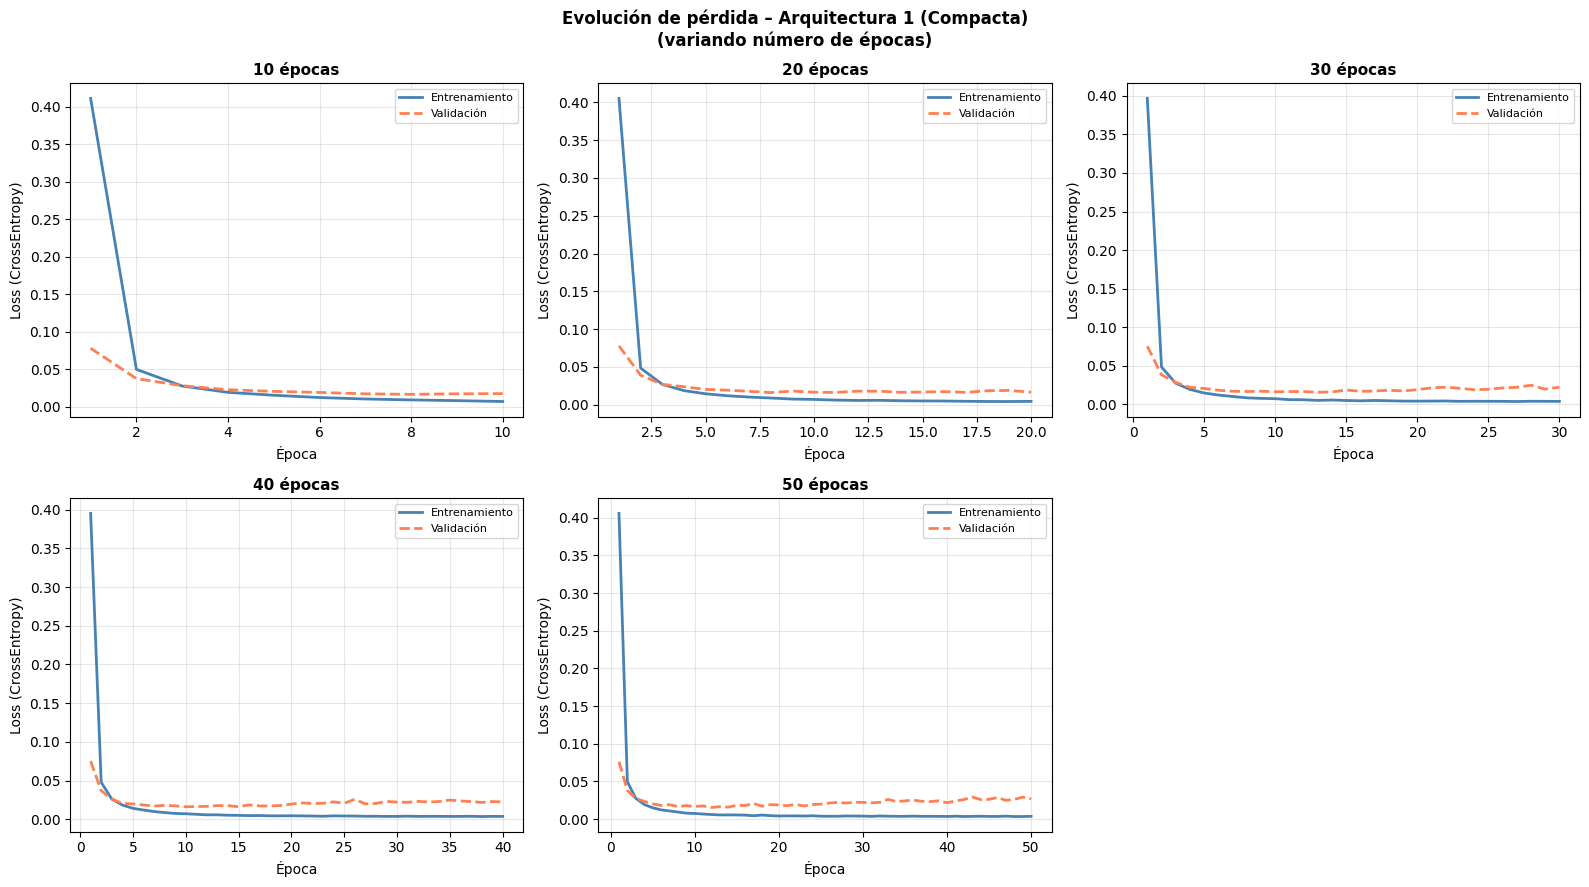

In [ ]:
# ── Configuración del experimento de épocas
EPOCAS_LISTA = [10, 20, 30, 40, 50]

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

resultados_epocas = {}   # métricas por número de épocas
historial_epocas  = {}   # curvas de pérdida por configuración

print(f"Mejor arquitectura seleccionada: {mejor_arq_nombre}")
print(f"Capas ocultas: {mejor_capas}\n")

for n_epocas in EPOCAS_LISTA:
    print(f"  Entrenando con {n_epocas} épocas...", end=' ')

    # ── Crear modelo desde cero en cada iteración
    modelo_ep = ANN(N_FEATURES, mejor_capas, N_CLASSES).to(DEVICE)
    opt_ep    = torch.optim.Adam(modelo_ep.parameters(), lr=LR)

    hist_tr, hist_vl = [], []
    t0 = time.time()

    for ep in range(1, n_epocas + 1):
        lt = entrenar_una_epoca(modelo_ep, train_loader, criterio, opt_ep)
        lv, _, _ = evaluar(modelo_ep, val_loader, criterio)
        hist_tr.append(lt)
        hist_vl.append(lv)

    tiempo_ep = time.time() - t0

    # ── Evaluar en TEST
    _, y_pred_ep, y_true_ep = evaluar(modelo_ep, test_loader, criterio)
    met = calcular_metricas(y_true_ep, y_pred_ep)
    met['tiempo'] = round(tiempo_ep, 1)

    resultados_epocas[n_epocas] = met
    historial_epocas[n_epocas]  = {'train': hist_tr, 'val': hist_vl}

    print(f"Acc={met['accuracy']:.4f}  F1={met['f1']:.4f}  t={tiempo_ep:.1f}s")


# ─── Gráficas de pérdida para cada configuración de épocas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, n_ep in enumerate(EPOCAS_LISTA):
    ax   = axes[i]
    hist = historial_epocas[n_ep]
    ax.plot(range(1, n_ep + 1), hist['train'], label='Entrenamiento',
            color='steelblue', lw=2)
    ax.plot(range(1, n_ep + 1), hist['val'],   label='Validación',
            color='coral', lw=2, ls='--')
    ax.set_title(f'{n_ep} épocas', fontsize=11, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (CrossEntropy)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)
fig.suptitle(f'Evolución de pérdida – {mejor_arq_nombre}\n'
             f'(variando número de épocas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.


In [ ]:
# ── Tabla resumen de épocas (valores reales)
filas_ep = []
for n_ep, m in resultados_epocas.items():
    filas_ep.append({
        'Épocas'                      : n_ep,
        'Accuracy'                    : round(m['accuracy'],  3),
        'Precision'                   : round(m['precision'], 3),
        'Recall'                      : round(m['recall'],    3),
        'F1-score'                    : round(m['f1'],        3),
        'Tiempo de entrenamiento (s)' : m['tiempo'],
    })

tabla_ep = pd.DataFrame(filas_ep).set_index('Épocas')
display(tabla_ep.style
        .background_gradient(subset=['Accuracy','F1-score'], cmap='YlGn')
        .format({'Accuracy':'{:.3f}','Precision':'{:.3f}',
                 'Recall':'{:.3f}','F1-score':'{:.3f}',
                 'Tiempo de entrenamiento (s)':'{:.1f}'})
        .set_caption(f'Tabla 2 – Impacto del número de épocas · {mejor_arq_nombre}'))

mejor_ep = tabla_ep['F1-score'].idxmax()
print(f"\nMejor número de épocas (F1-score): {mejor_ep}")


,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
Épocas,,,,,
10,0.883,0.889,0.883,0.884,12.2
20,0.885,0.889,0.885,0.885,24.4
30,0.891,0.897,0.891,0.891,37.0
40,0.868,0.876,0.868,0.869,50.8
50,0.869,0.881,0.869,0.869,63.4



Mejor número de épocas (F1-score): 30


---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

---

### 1. ¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?

La Arquitectura 4 (Pirámide profunda) [512, 256, 128, 64] fue la mejor. Obtuvo el mayor F1-score y accuracy en testeo con un tiempo de entrenamiento razonable. Tiene suficiente profundidad para aprender los patrones de las 520 señales WAP sin volverse innecesariamente costosa como la Arquitectura 5.

---

### 2. ¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?

La Arquitectura 1 (Compacta) [128]. Con una sola capa oculta de solo 128 neuronas para procesar 520 features, la red sufrió underfitting: no tuvo capacidad suficiente para aprender las relaciones entre las señales WiFi y el piso, resultando en métricas notablemente más bajas.

---

### 3. ¿Cómo influye el número de capas ocultas en el comportamiento de la red?

Más capas mejoran el rendimiento hasta cierto punto. De la Arquitectura 1 a la 4 se observa mejora progresiva porque la red aprende representaciones más complejas. Sin embargo, la Arquitectura 5, siendo la más profunda, no siempre supera a la 4, mostrando que sin regularización (Dropout, BatchNorm) agregar más capas puede no aportar mejoras reales.

---

### 4. ¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.

Aproximadamente 30 épocas. En las curvas del Paso 7, a partir de ese punto la pérdida de validación se estabiliza y las métricas en testeo dejan de mejorar. Con 40–50 épocas el tiempo aumenta pero el F1-score ya no sube, e incluso aparece una leve divergencia entre la pérdida de entrenamiento y validación.
---

### 5. ¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?

Sí. La Arquitectura 1 mostró subajuste: pérdida alta en entrenamiento y validación durante todas las épocas. La Arquitectura 5 con muchas épocas mostró indicios de sobreajuste: la pérdida de entrenamiento seguía bajando mientras la de validación se estancaba o subía levemente, visible en las gráficas del Paso 7.
---

### 6. ¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?

La Arquitectura 5 fue la más lenta por tener capas de hasta 1024 neuronas, pero sus métricas no superaron significativamente a la Arquitectura 4. De igual forma, entrenar con 40–50 épocas tomó más tiempo que con 30, sin ganancia real en F1-score. Más parámetros y más épocas no siempre compensan el costo computacional.

---

### 7. ¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?

No. La Arquitectura 5, siendo la más profunda y ancha, no obtuvo necesariamente el mejor resultado. El dataset UJIIndoorLoc es tabular y no requiere redes extremadamente grandes. Una arquitectura moderada como la 4 logra mejor balance entre capacidad y generalización, especialmente sin regularización.

---

### 8. ¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?

El F1-score ponderado. El dataset tiene cierto desbalance entre pisos (no todos tienen la misma cantidad de muestras), lo que hace que el accuracy solo pueda ser engañoso. El F1-score considera tanto precision como recall para cada clase según su proporción, dando una medida más justa del rendimiento real en todos los pisos del edificio.
---
# Nueva sección

---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)               | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---
